# Section 1: Introduction and Model Selection
The chosen system for this project is "Spring-Mass System (Mechanical Oscillations)". This is the equation that governs that system. $$m\frac{d^{2}y}{dt^{2}} + c\frac{dy}{dt} + ky = 0$$ Let:
$$y_1 = y$$
$$y_2 = \frac{dy}{dt}$$

Then the system is:
$$\begin{cases} \frac{dy_1}{dt} = y_2 \\ \frac{dy_2}{dt} = \frac{-(c y_2 + k y_1)}{m} \end{cases}$$
This models the vertical displacement of one corner of a car (quarter car suspension system), where there is a spring mass (undampened). Y1 represents the displacement from the equilibrium state for the spring. Y2 represents the velocity moving in the vertical direction. M is the sprung mass which represents the mass supported by that spring at that corner of the car. C is the damping coefficient which represents the resistance provided by the shock to absord and dissipate the energy. K is the spring constant which represents the stiffness of the spring which resists compression of it. Units for m are in kg, C in N * s/m, and K in N/m. 

# Section 2: Parameter Research and Justification

| Parameter | Symbol | Value | Units |
| :--- | :---: | :---: | :--- |
| **Sprung Mass** | $m$ | 360 | kg |
| **Spring Constant** | $k$ | 20,000 | N/m |
| **Damping Coefficient** | $c$ | 2,000 | Ns/m | 


Here is the link to the research that provided these values for the 2019 Honda Civic LX passenger car: https://www.researchgate.net/publication/356324043_Modeling_Analysis_and_Simulation_of_Wheel_Suspension_System's_Response_for_Quarter_Car_Model_by_Using_20-sim_Software_for_Honda_Civic_Lx_2019_Sedan

Initial Conditions:
Initial Displacement: (y_0): 0.0762 m (3 inches). 
Initial Velocity (v_0): 0 m/s.]
Justification: The displacement of 3 inches was chosen as this value models a typical displacement of a noticeable speed bump or deep pothole, which are both likely to be encountered on the road. The initial velocity of 0 was chosen because this models the start of the recover phase just when the spring is finished moving from the speedbump/pothole.

Description of Scenario: This models the corner of a car where it (mass of 360k) experiences this displacement either from a pothole or a speedbump. The spring will be moved and the oscillation will start as it returns back to equilibrium (y=0) rather quickly. 

# Section 3: Numerical Methods Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#The two functions that were derived at the beginning.
def f1(v_n):
    return v_n

def f2(m,k,c, y_n, v_n):
    return (-(c * v_n + k * y_n) / m)


#Inputs for euler method are the 2 time points for the bounds, the starting position 
# and velocity, the step size, and then the spring constants. 
def euler_method(t_start, t_end, y_0, v_0, h, m,k,c):
    #create the t values using the unique step size h, and creates empty position and velocity lists
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(t_values))
    # Set initial conditions
    y_values[0] = y_0
    v_values[0] = v_0
    for i in range(1, len(t_values)):
        #Gets the previous position and velocity
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]
        # Updates values for Euler's Method
        y_values[i] = y_n + h * f1(v_n)
        v_values[i] = v_n + h * f2(m,k,c,y_n,v_n)
    return t_values, y_values, v_values


#Inputs for euler method are the 2 time points for the bounds, the starting position 
# and velocity, the step size, and then the spring constants. 
def runge_kutta_4(t0, tf,y0,v0,h,m,k,c):
    def f(m,k,c, y_n, v_n):
        #This is the equation that models the change in velocity. Creates a function that can execute it
        return (-(c * v_n + k * y_n) / m)
    # Create an array for time steps
    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(t_values))
    # Set the initial condition
    y_values[0] = y0
    v_values[0] = v0
    # Perform the RK4 iteration
    for i in range(1, len(t_values)):
        t = t_values[i - 1]
        y = y_values[i - 1]
        v = v_values[i - 1]
        # k1
        k1y = h * v
        k1v = h * f(m,k,c,y,v)
        # k2
        k2y = h * (v + k1v/2)
        k2v = h * f(m,k,c,(y+ k1y/2),(v+ k1v/2))
        # k3
        k3y = h * (v + k2v/2)
        k3v = h * f(m,k,c,(y+k2y/2),(v+k2v/2))
        # k4
        k4y = h * (v + k3v)
        k4v = h * f(m,k,c,(y+k3y),(v+k3v))
        
        # Update y based on the formula. The two middle bounds get weighted twice as heavy 
        # according to the formula.
        y_values[i] = y + (k1y + 2 * k2y + 2 * k3y + k4y) / 6
        v_values[i] = v + (k1v + 2*k2v + 2*k3v + k4v) / 6
    return t_values, y_values, v_values


The two functions here are similar but have important differences. The euler method just 
takes the previous velocity and acceleration and adjust the position and velocity 
accordingly. The runge kutta however gets and average of changes. These are 4 values with
the first being like euler, but then it gets two middle approximation that are in between 
the time steps. The last one is at the next point. Then these 4 are averaged out and that 
is the updated position and velocity. 

# Section 4: Solutions and Comparison

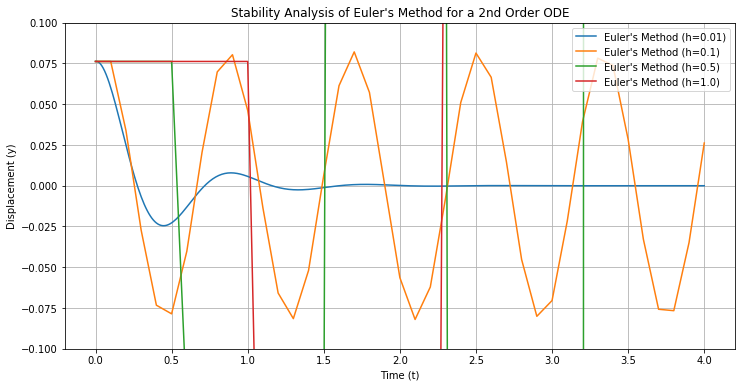

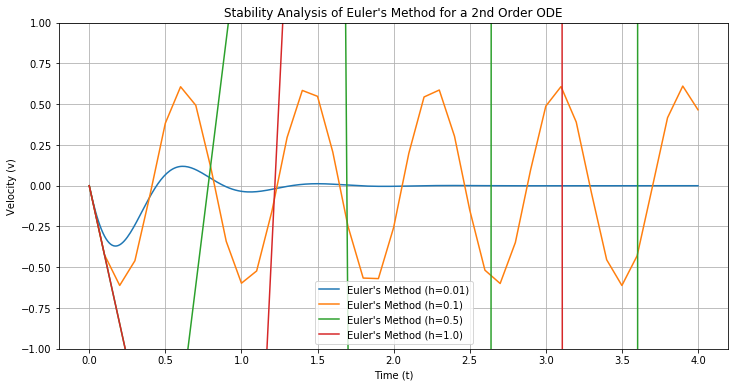

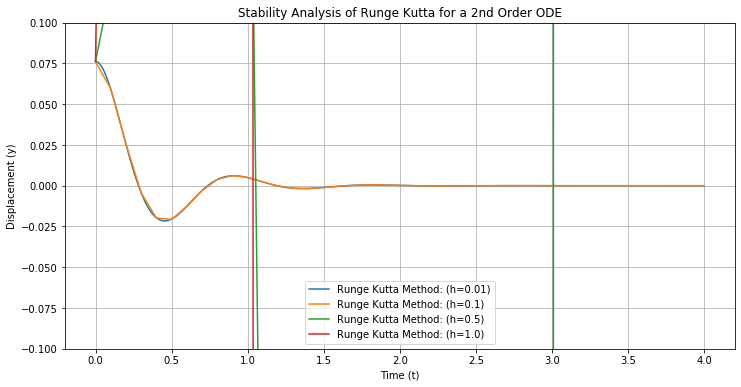

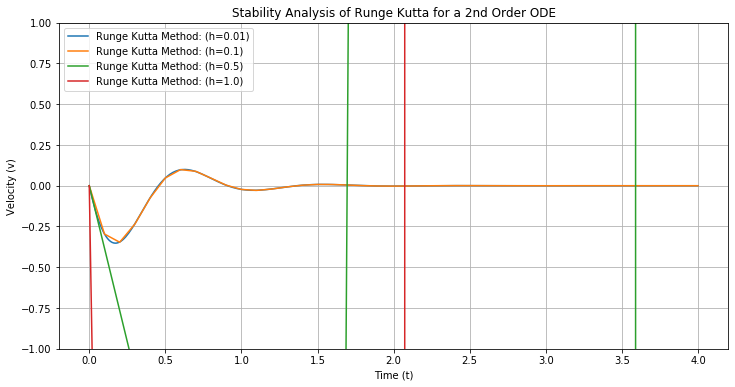

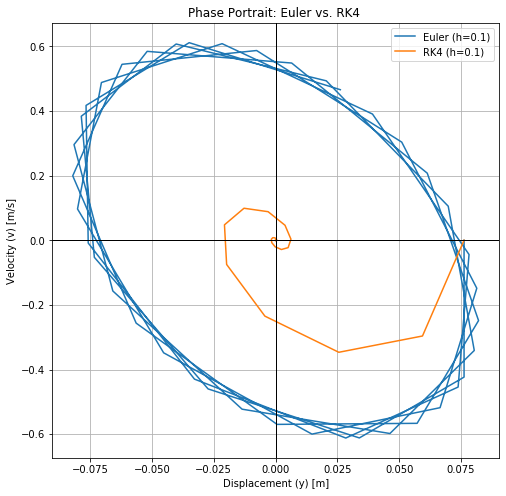

In [2]:
h_values = [0.01, 0.1, 0.5, 1.0] 

#Euler below
plt.figure(figsize=(12, 6))
for h in h_values:
    t, y, v = euler_method(0,4,0.0762,0,h,360,20000,2000)
    plt.plot(t, y, label=f'Euler\'s Method (h={h})')
plt.ylim(-0.1, 0.1)
plt.xlabel('Time (t)')
plt.ylabel('Displacement (y)')
plt.title('Stability Analysis of Euler\'s Method for a 2nd Order ODE')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
for h in h_values:
    t, y, v = euler_method(0,4,0.0762,0,h,360,20000,2000)
    plt.plot(t, v, label=f'Euler\'s Method (h={h})')
plt.ylim(-1, 1)
plt.xlabel('Time (t)')
plt.ylabel('Velocity (v)')
plt.title('Stability Analysis of Euler\'s Method for a 2nd Order ODE')
plt.legend()
plt.grid(True)
plt.show()


#Runge Kutta Below

plt.figure(figsize=(12, 6))
for h in h_values:
    t, y, v = runge_kutta_4(0,4,0.0762,0,h,360,20000,2000)
    plt.plot(t, y, label=f'Runge Kutta Method: (h={h})')
plt.ylim(-0.1, 0.1)
plt.xlabel('Time (t)')
plt.ylabel('Displacement (y)')
plt.title('Stability Analysis of Runge Kutta for a 2nd Order ODE')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
for h in h_values:
    t, y, v = runge_kutta_4(0,4,0.0762,0,h,360,20000,2000)
    plt.plot(t, v, label=f'Runge Kutta Method: (h={h})')
plt.ylim(-1, 1)
plt.xlabel('Time (t)')
plt.ylabel('Velocity (v)')
plt.title('Stability Analysis of Runge Kutta for a 2nd Order ODE')
plt.legend()
plt.grid(True)
plt.show()


# Phase Portrait Below
plt.figure(figsize=(8, 8))
# Euler at h= 0.1
t_e, y_e, v_e = euler_method(0, 4, 0.0762, 0, 0.1, 360, 20000, 2000)
plt.plot(y_e, v_e, label='Euler (h=0.1)')
#Runge kutta Below at same h value
t_r, y_r, v_r = runge_kutta_4(0, 4, 0.0762, 0, 0.1, 360, 20000, 2000)
plt.plot(y_r, v_r, label='RK4 (h=0.1)')

#Add y and x axis lines for visual aid
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.xlabel('Displacement (y) [m]')
plt.ylabel('Velocity (v) [m/s]')
plt.title('Phase Portrait: Euler vs. RK4 ')
plt.legend()
plt.grid(True)
plt.show()


Discussion of visual results: For both euler and runge kutta, we can see that the two smaller h values of 0.01 and 0.1 demonstrate occilation. In euler, the smalles the h value line returns to 0 after about two seconds which is what we would expect. The 0.1 h value is seen ocillating and slowly getting back towards zero but yet it doesn't at the end of the four seconds. So the only h value that predicted it correctly was the smallest. The biggest of the two h values simply blew up immediately and are off the graph as the y limits are -0.1 and 0.1. The same can be seen in the euler velocity graph, where only the h = 0.01 correctly goes back to zero, but the h = 0.1 can still be seen to ocillate while the largest two go out of the graph. As for the runge kutta, in the position graph you can see that both of the smallest h values are following the expected trend, with the h=0.1 just being slightly slightly off compared to the 0.01 h value. But they both return to equilibrium while the other two h values blow up. The exact same can be said for the velocity graph of the runge kutta. 
Finally, the last graph shows how both euler and runge kutta start at the 0.075 displacement, but the runge kutta gets to a displacement and velocity of zero at the end of the 4 seconds, however the euler method had not and it was stuck going in a loop. This shows the the euler method was not accurate enough at h = 0.1, but runge kutta was.

# Section 5: Stability Analysis
This is the link for the equation that models the analytical solution for an undamped system. We know it is undamped because the damping ratio $$(c / sqrt(m*k))$$ is 0.37. Here is the link: https://www.uml.edu/docs/second-initial_tcm18-190095.pdf . The full equation for a system is as follows: $$y(t) = e^{-\zeta \omega_n t} \left[ y_0 \cos(\omega_d t) + \left( \frac{v_0 + \zeta \omega_n y_0}{\omega_d} \right) \sin(\omega_d t) \right]$$ with the physical paramters defined as: $$\omega_n = \sqrt{\frac{k}{m}}$$  $$\zeta = \frac{c}{2\sqrt{mk}}$$  $$\omega_d = \omega_n \sqrt{1 - \zeta^2}$$

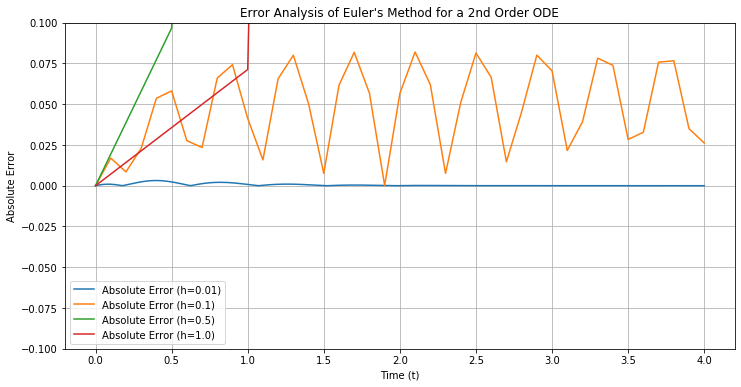

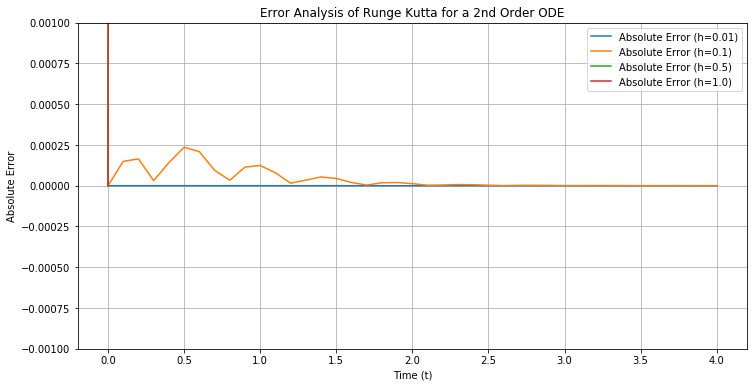

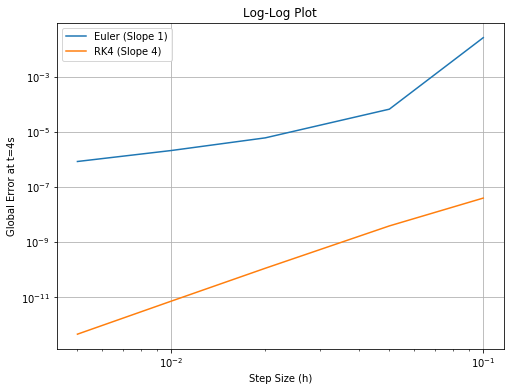

In [3]:
def exact_solution(t, m, k, c, y0, v0):
    # Calculate the physical constants
    omega_n = np.sqrt(k / m)
    zeta = c / (2 * np.sqrt(m * k))
    omega_d = omega_n * np.sqrt(1 - zeta**2)
    
    # Calculate the displacement at time t
    envelope = np.exp(-zeta * omega_n * t)
    oscillation = y0 * np.cos(omega_d * t) + ((v0 + (zeta * omega_n * y0)) / omega_d) * np.sin(omega_d * t)
    return envelope * oscillation

#Euler below
plt.figure(figsize=(12, 6))
for h in h_values:
    t, y, v = euler_method(0,4,0.0762,0,h,360,20000,2000)
    y_exact = exact_solution(t,360,20000,2000,0.0762,0)
    error = np.abs(y_exact - y )
    plt.plot(t, error, label=f'Absolute Error (h={h})')
plt.ylim(-0.1, 0.1)
plt.xlabel('Time (t)')
plt.ylabel('Absolute Error')
plt.title('Error Analysis of Euler\'s Method for a 2nd Order ODE')
plt.legend()
plt.grid(True)
plt.show()

# Runge Kutta below
plt.figure(figsize=(12, 6))
for h in h_values:
    t, y, v = runge_kutta_4(0,4,0.0762,0,h,360,20000,2000)
    y_exact = exact_solution(t,360,20000,2000,0.0762,0)
    error = np.abs(y_exact - y )
    plt.plot(t, error, label=f'Absolute Error (h={h})')
plt.ylim(-0.001, 0.001)
plt.xlabel('Time (t)')
plt.ylabel('Absolute Error')
plt.title('Error Analysis of Runge Kutta for a 2nd Order ODE')
plt.legend()
plt.grid(True)
plt.show()



# Log Graph section
h_test = [0.1, 0.05, 0.02, 0.01, 0.005]
euler_final_errors = []
rk4_final_errors = []

# True value at ending time of 4
y_true_final = exact_solution(4, 360, 20000, 2000, 0.0762, 0)

for h in h_test:
    # Run Euler and grab the last y value
    t_e, y_e, v_e = euler_method(0, 4, 0.0762, 0, h, 360, 20000, 2000)
    euler_final_errors.append(np.abs(y_true_final - y_e[-1]))
    
    # Run RK4 and grab the last y value
    t_r, y_r, v_r = runge_kutta_4(0, 4, 0.0762, 0, h, 360, 20000, 2000)
    rk4_final_errors.append(np.abs(y_true_final - y_r[-1]))

# 3. Create the Log-Log Plot
plt.figure(figsize=(8, 6))
plt.loglog(h_test, euler_final_errors, label='Euler (Slope 1)')
plt.loglog(h_test, rk4_final_errors, label='RK4 (Slope 4)')

plt.xlabel('Step Size (h)')
plt.ylabel('Global Error at t=4s')
plt.title('Log-Log Plot')
plt.legend()
plt.grid(True)
plt.show()

Discussion for section 5: The error plots above show the euler and runge katta methods on two different graphs. For the euler method, the y bounds are -0.1 to 0.1, which is enough to show how the ocillation of the h = 0.1, which never gets its error down to zero since in the previous graphs we saw it never got it back to equilibrium in the four second window. Meanwhile the h = 0.01 did get to equilibrium, as shown by the absolute error of zero it reaches. The h= 0.01 has a slight error ocillation but quickly gets to equilibrium. The larger of the two h values are so big that they go completely off the graph. The runge kutta on the other hand shows that the smallest h value has essentially zero error, while the h = 0.1, which with euler never got to the equilibrium of zero error, did get to equilibrium after about two seconds. The log graph of error shows how the euler error was much larger comparatively compared to the RK4. This is because the euler starts at 10^-6 going upwards, however the runge kutta starts much lower at 10^-12 and only goes up to 10^-7 (which is a much smaller number). 
Stability limits: These graphs show that the stability limit for euler is essentially just the smallest h value of 0.01 (with h=0.1 eventually reaching equilibrium if the time window was large enough). The largest h values of 0.5 and 1 were not stable at all and immediately blow up as their error's start to compund. With the real spring essentially settling in under a second, the h value of 1 second overshoots the whole process. We can see with these error plots and the previous y-position and velocity graphs that the largest 2 h values are simply not stable at all and shoot to absurd values that are not realistic for a car shock displacement.  

# Section 6: Conclusion
The method that performed better for this problem was the runge kutta, which worked well with the two smaller h values of 0.01 and 0.1, while the euler only worked well enough with the smallest h value of 0.01. The better method between the two is the runge kutta. The runge kutta is also better because to use euler, we would have to use the 0.01 h value, which increases computational time. But if we use the runge kutta method, we can do less total iterations by using h = 0.1, which is still accurate for our model. This means that runge kutta allows us to stay accurate with a lower computational cost. Practical reccomendations for this would be to find the exact stability limit, which is essentially somewhere in between h = 0.1 and h = 0.5, because when jumping from these two, the models then started to overshoot wildly at h = 0.5. A lesson learned is that the runge kutta method is a computationally cheaper method of getting a perfectly reasonable accurate simulation, and that there sometimes is no benefit to going to such a small h value because we just need something good enough, not perfect. Perfect is expensive. 